# Physics-Informed MSCNN: Neural Networks with Physics Regularization

This notebook explains how the **PhysicsInformedMSCNN** model implements a Physics-Informed Neural Network (PINN) for solar atmospheric inversion. Unlike standard supervised learning, this approach combines:

1. **Supervised loss**: MSE between network predictions and MURaM atmospheric parameters
2. **Physics regularization**: Constraints from physical approximations (WFA for B_LOS, Doppler for V_LOS)

The key innovation is computing **tau-averaged** quantities from the predicted atmospheric profiles, which are then compared against physics approximations (WFA, Doppler) computed from the Stokes observations.


## 1. Import Required Libraries


In [1]:
import sys
import numpy as np
from pathlib import Path

sys.path.append("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/")
sys.path.append("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/")
sys.path.append("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/models/")

import torch
import torch.nn as nn
import torch.optim as optim
import astropy.units as u
import matplotlib.pyplot as plt

from models.pinn_mscnn_model import PhysicsInformedMSCNN
from utils.physics_utils import ApproxInversions
from utils.muram_data import MhdData, StokesData, MhdNormalizer

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Libraries imported successfully!
PyTorch version: 2.6.0+cu124
CUDA available: True


## 2. Instantiate the PhysicsInformedMSCNN Model

The `PhysicsInformedMSCNN` extends the standard `MSCNNInversionModel` with physics-aware training capabilities. Key parameters control the physics regularization:

- **use_physics**: Controls which physics regularization to apply:
  - `None`: No physics regularization (pure supervised learning)
  - `'wfa'`: Only WFA B_LOS regularization
  - `'doppler'`: Only Doppler V_LOS regularization
  - `'both'`: Both WFA and Doppler regularization
- **lambda_wfa**: Weight for WFA B_LOS loss term
- **lambda_doppler**: Weight for Doppler V_LOS loss term
- **lambda_physics**: Weight for gradient smoothness regularization

In [2]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the Physics-Informed MSCNN model
model = PhysicsInformedMSCNN(
    scales=[1, 2, 3],                           # Multi-scale coarse-graining
    in_channels=2,                              # I and V Stokes parameters
    c1_filters=16,                              # Filters in first conv block
    c2_filters=32,                              # Filters in second conv block
    kernel_size=5,                              # Convolution kernel size
    pool_size=2,                                # MaxPool kernel size
    n_linear_layers=4,                          # Dense layers for final mapping
    output_features=3*21,                       # 3 parameters × 21 heights = 63 outputs
    input_length=112,                           # Spectral dimension of Stokes profiles
    
    # Physics-informed parameters
    use_physics='both',                         # Use both WFA and Doppler (can be None, 'wfa', 'doppler', or 'both')
    lambda_wfa=0.01,                            # Weight for WFA B_LOS loss
    lambda_doppler=0.01,                        # Weight for Doppler V_LOS loss
    lambda_physics=0.001,                       # Weight for gradient smoothness

    # Dropout for uncertainty
    dropout_rate=0.2  # 20% dropout
).to(device)

print(f"Model instantiated on {device}")
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Physics mode: {model.use_physics}")
print(f"Lambda WFA: {model.lambda_wfa}, Lambda Doppler: {model.lambda_doppler}, Lambda Physics: {model.lambda_physics}")

Using device: cuda
Model instantiated on cuda
Total trainable parameters: 7,318,223
Physics mode: both
Lambda WFA: 0.01, Lambda Doppler: 0.01, Lambda Physics: 0.001


## 3. Understanding the Physics-Informed Loss Function

The loss combines multiple components:

$$\mathcal{L}_{\text{total}} = \underbrace{\text{MSE}(\hat{y}, y)}_{\text{supervised}} + \lambda_{\text{wfa}} \cdot \underbrace{\text{MSE}\big(B_{\text{LOS}}^{\text{WFA}}, \langle B_z^{\text{pred}} \rangle_\tau\big)}_{\text{WFA regularization}} + \lambda_{\text{doppler}} \cdot \underbrace{\text{MSE}\big(v_{\text{LOS}}^{\text{Doppler}}, \langle v_z^{\text{pred}} \rangle_\tau\big)}_{\text{Doppler regularization}} + \lambda_{\text{physics}} \cdot \underbrace{\mathcal{L}_{\text{smooth}}}_{\text{gradient smoothness}}$$

Where:
- $\hat{y}$: Network predictions (atmospheric parameters at 21 heights)
- $y$: Ground truth from MURaM simulations
- $B_{\text{LOS}}^{\text{WFA}}$: Weak-Field Approximation magnetic field from Stokes profiles
- $v_{\text{LOS}}^{\text{Doppler}}$: Doppler-shift velocity from Stokes profiles
- $\langle B_z^{\text{pred}} \rangle_\tau$ and $\langle v_z^{\text{pred}} \rangle_\tau$: **Tau-averaged** model predictions using trapezoidal integration

The tau-averaging follows:
$$\langle Q \rangle_\tau = \frac{\int Q(\tau) d\tau}{\int d\tau}$$

## 4. Data Preparation: Loading MURaM Simulations

First, we need to load MHD and Stokes data from MURaM simulations. The `MhdData` and `StokesData` classes handle this:


In [ ]:
# Data paths (adjust to your system)
data_path = Path("/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/data/")
step = 112  # Choose a simulation step

# Load MHD data and remap to optical depth
mhd = MhdData(
    data_path=data_path / "muram-simulation",
    nx=480, ny=480, nz=256
)
mhd.load_step(step=step, z_max=250)
mhd.load_opacity_table(kappa_path=data_path / "csv/kappa.0.dat")
mhd.compute_optical_depth(dz=10*u.km)

# Create a uniform log(tau) grid for remapping
new_logtau = np.arange(-2.0, 0.1, 0.1)
mhd.remap_to_optical_depth(new_logtau, quantities=["T", "Vz", "Bz"])

print(f"MHD data loaded: {mhd.od_data['Bz'].shape}")
print(f"Log(tau) values: {new_logtau}")

# Load Stokes data
stokes = StokesData(
    data_dir=data_path / "muram-simulation/",
    step=step,
    wavelength_range=(6300.5, 6303.5),
    wavelength_step=0.01
)
stokes.load_stokes()
stokes.continuum_normalization(cont_indices=[0, 1, 2, 3])
stokes.load_hinode_lsf(data_path / "hinode-MODEST/PSFs/hinode_sp.spline.psf")
stokes.apply_spectral_convolution()
stokes.resample_to_hinode()

print(f"Stokes data loaded: {stokes.data['I'].shape}")
print(f"Stokes wavelength range: {stokes.wl.min():.2f} - {stokes.wl.max():.2f} Å")

Loading step 112000
  Trimmed z axis to first 250 layers (0..249)
  Reference layer (T ~ 5780 K) at z-index 186
  Done.
Opacity interpolator loaded from /scratchsan/observatorio/juagudeloo/data/csv/kappa.0.dat
  T range: [3.320, 5.300] (log10 K)
  P range: [-2.000, 8.000] (log10 dyne/cm²)
Computing optical depth...
  Optical depth computed.
Remapping to optical depth coordinates (21 levels)...
  Processing T
  Processing Vz
  Processing Bz
  Remapping complete.
MHD data loaded: (480, 480, 21)
Log(tau) values: [-2.00000000e+00 -1.90000000e+00 -1.80000000e+00 -1.70000000e+00
 -1.60000000e+00 -1.50000000e+00 -1.40000000e+00 -1.30000000e+00
 -1.20000000e+00 -1.10000000e+00 -1.00000000e+00 -9.00000000e-01
 -8.00000000e-01 -7.00000000e-01 -6.00000000e-01 -5.00000000e-01
 -4.00000000e-01 -3.00000000e-01 -2.00000000e-01 -1.00000000e-01
  1.77635684e-15]
Loading Stokes data from /scratchsan/observatorio/juagudeloo/data/muram-simulation/stokes_112000.npy
  I shape: (480, 480, 300)
  Q shape: (48

## 5. Compute WFA-based B_LOS Approximation

The Weak-Field Approximation (WFA) relates Stokes V to the line-of-sight magnetic field:

$$V \approx -\frac{e}{4\pi m_e c} \lambda_0^2 g_\lambda B_{\text{LOS}} \frac{dI}{d\lambda}$$

The `ApproxInversions` class solves this using least-squares fitting to estimate $B_{\text{LOS}}$ from observations.


<>:30: SyntaxWarning: invalid escape sequence '\l'
<>:30: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_231820/2610658628.py:30: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_title(f'MHD $B_z$ at $\log\\tau$ = {new_logtau[ref_height]:.1f}')


B_LOS (WFA) computed: shape (480, 480), range [-527.4 G, 560.1 G]


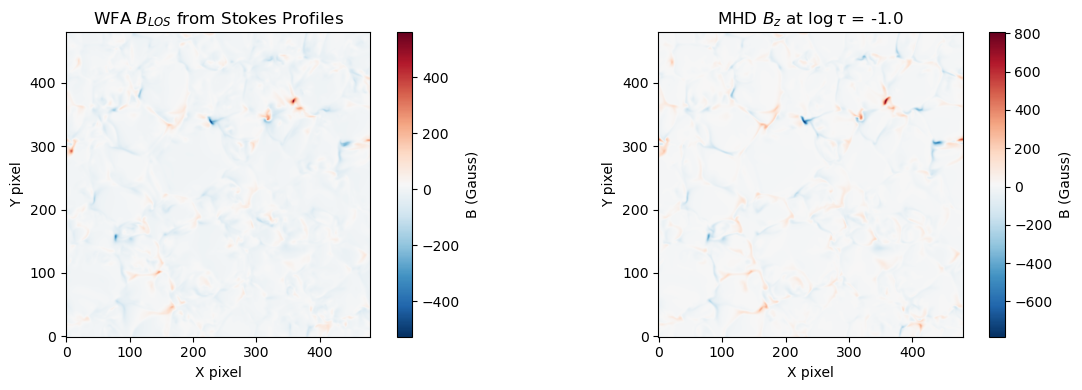

In [4]:
# Create ApproxInversions object
inversions = ApproxInversions(
    stokes=stokes.data,
    wavelength=stokes.wl,
    central_wavelength=6301.5*u.Angstrom,
    lande_factor=1.67
)

# Define wavelength range for physics calculations
wl_range = [15, 60]

# Compute B_LOS using WFA
blos = inversions.compute_blos_wfa(wl_range=wl_range)
print(f"B_LOS (WFA) computed: shape {blos.shape}, range [{blos.min():.1f}, {blos.max():.1f}]")

# Visualize B_LOS map
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# WFA B_LOS
im0 = axes[0].imshow(blos.value, origin='lower', cmap='RdBu_r')
axes[0].set_title('WFA $B_{LOS}$ from Stokes Profiles')
axes[0].set_xlabel('X pixel')
axes[0].set_ylabel('Y pixel')
plt.colorbar(im0, ax=axes[0], label='B (Gauss)')

# MHD Bz at a reference height (middle of optical depth range)
ref_height = len(new_logtau) // 2
mhd_bz_ref = mhd.od_data['Bz'].value[:, :, ref_height]
im1 = axes[1].imshow(mhd_bz_ref, origin='lower', cmap='RdBu_r')
axes[1].set_title(f'MHD $B_z$ at $\log\\tau$ = {new_logtau[ref_height]:.1f}')
axes[1].set_xlabel('X pixel')
axes[1].set_ylabel('Y pixel')
plt.colorbar(im1, ax=axes[1], label='B (Gauss)')

plt.tight_layout()
plt.show()

## 6. Compute Doppler-based V_LOS Approximation

The Doppler formula relates wavelength shift to velocity:

$$v_{\text{LOS}} = \frac{\lambda_0 - \lambda_{\text{fit}}}{\lambda_0} c$$

where $\lambda_{\text{fit}}$ is found by fitting a Gaussian to the Stokes I profile.


<>:18: SyntaxWarning: invalid escape sequence '\l'
<>:18: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_231820/419287339.py:18: SyntaxWarning: invalid escape sequence '\l'
  axes[1].set_title(f'MHD $v_z$ at $\log\\tau$ = {new_logtau[ref_height]:.1f}')
/scratchsan/observatorio/juagudeloo/Tesis_maestria_OAN/utils/physics_utils.py:180: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(


V_LOS (Doppler) computed: shape (480, 480), range [-18.2 km / s, 4.5 km / s]


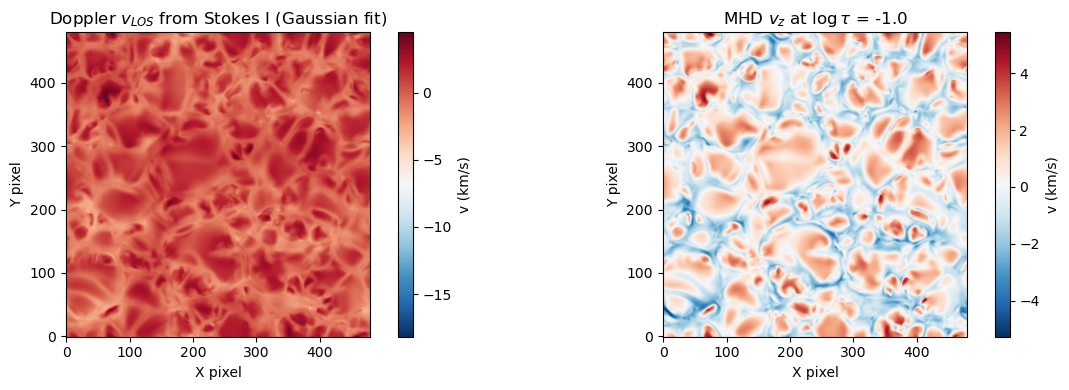

In [5]:
# Compute V_LOS using Doppler shift (Gaussian fitting)
vlos = inversions.compute_vlos_doppler(wl_range=wl_range)
print(f"V_LOS (Doppler) computed: shape {vlos.shape}, range [{np.nanmin(vlos):.1f}, {np.nanmax(vlos):.1f}]")

# Visualize V_LOS map
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Doppler V_LOS
im0 = axes[0].imshow(vlos.value, origin='lower', cmap='RdBu_r')
axes[0].set_title('Doppler $v_{LOS}$ from Stokes I (Gaussian fit)')
axes[0].set_xlabel('X pixel')
axes[0].set_ylabel('Y pixel')
plt.colorbar(im0, ax=axes[0], label='v (km/s)')

# MHD Vz at a reference height
mhd_vz_ref = mhd.od_data['Vz'].value[:, :, ref_height]
im1 = axes[1].imshow(mhd_vz_ref, origin='lower', cmap='RdBu_r')
axes[1].set_title(f'MHD $v_z$ at $\log\\tau$ = {new_logtau[ref_height]:.1f}')
axes[1].set_xlabel('X pixel')
axes[1].set_ylabel('Y pixel')
plt.colorbar(im1, ax=axes[1], label='v (km/s)')

plt.tight_layout()
plt.show()

## 7. Compute Tau-Averaged MHD Quantities

The physics-informed loss compares approximations against **tau-averaged** predictions. Let's visualize how tau-averaging works on the MHD ground truth:

$$\langle Q \rangle_\tau = \frac{\int Q(\tau) d\tau}{\int d\tau}$$

This integration weights contributions from all optical depths, matching the physical reality that spectral lines sample multiple atmospheric layers.


Tau-averaged Bz shape: (480, 480)
Tau-averaged Vz shape: (480, 480)

B_LOS vs Tau-Averaged Bz: Corr = 0.7799, RMSE = 30.73 G
V_LOS vs Tau-Averaged Vz: Corr = 0.8833, RMSE = 1.01 km/s


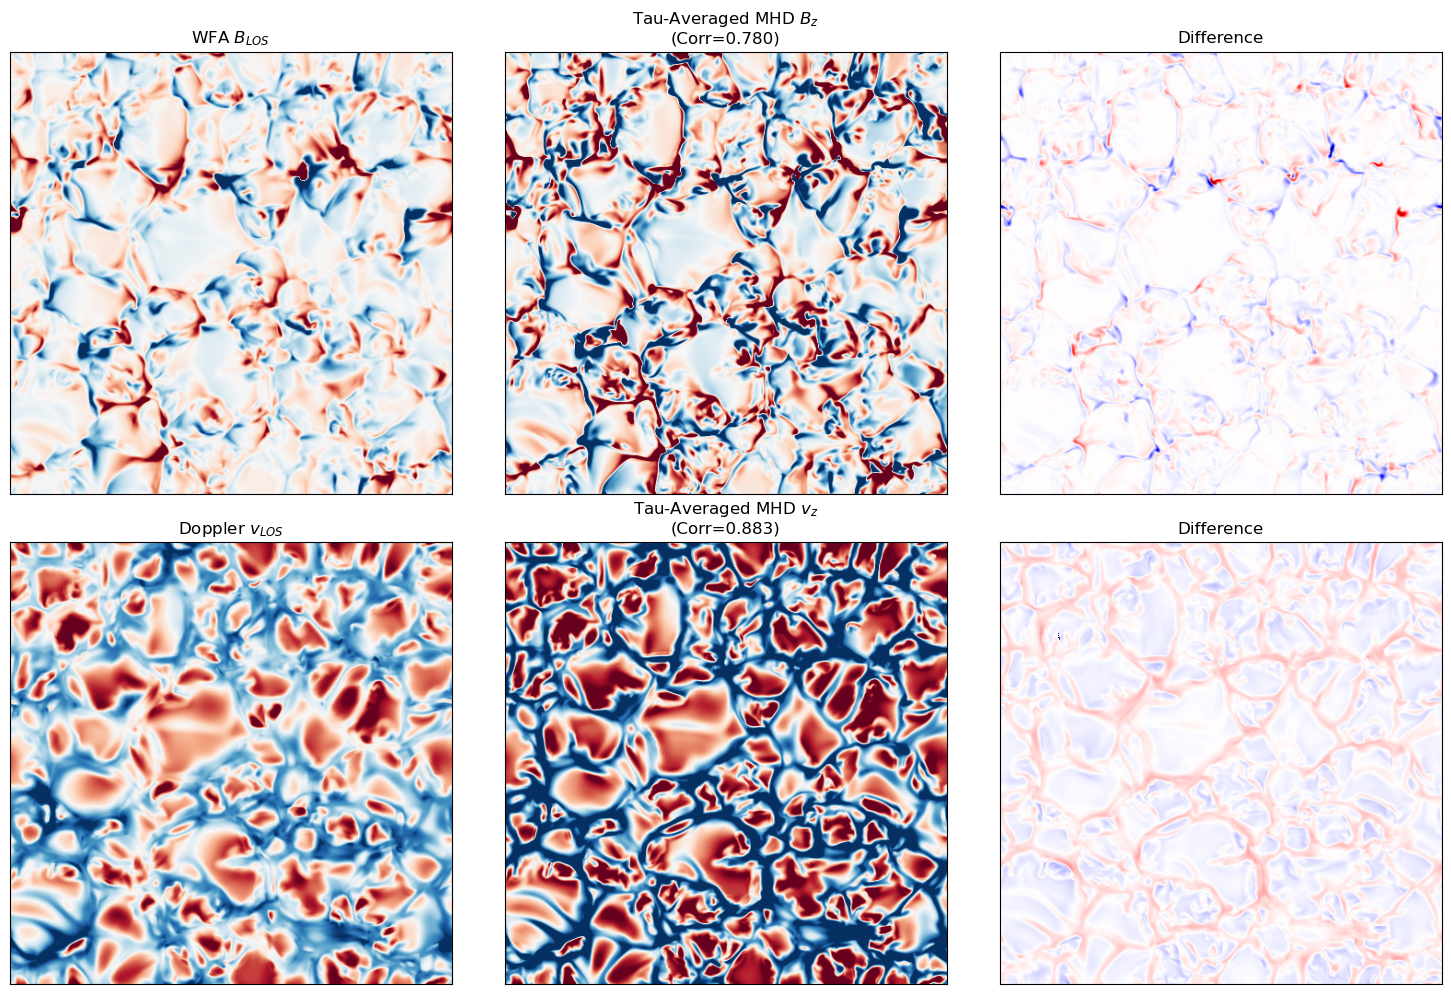

In [6]:
# Compute tau-averaged MHD quantities for comparison
def compute_tau_averaged(cube_3d: np.ndarray, logtau: np.ndarray) -> np.ndarray:
    """Compute tau-averaged quantity using trapezoidal integration."""
    tau_linear = 10 ** logtau
    dtau = np.diff(tau_linear)
    
    # Average between consecutive points
    q_avg = (cube_3d[:, :, :-1] + cube_3d[:, :, 1:]) / 2
    
    # Trapezoidal integration
    integral_q = np.sum(q_avg * dtau[np.newaxis, np.newaxis, :], axis=2)
    integral_dtau = tau_linear[-1] - tau_linear[0]
    
    return integral_q / integral_dtau

# Compute tau-averaged Bz and Vz
mhd_bz_tau_avg = compute_tau_averaged(mhd.od_data['Bz'].value, new_logtau)
mhd_vz_tau_avg = compute_tau_averaged(mhd.od_data['Vz'].value, new_logtau)

print(f"Tau-averaged Bz shape: {mhd_bz_tau_avg.shape}")
print(f"Tau-averaged Vz shape: {mhd_vz_tau_avg.shape}")

# Compare approximations with tau-averaged MHD
from scipy.stats import pearsonr

# B_LOS comparison
blos_np = blos.value
corr_blos, _ = pearsonr(blos_np.flatten(), mhd_bz_tau_avg.flatten())
rmse_blos = np.sqrt(np.mean((blos_np - mhd_bz_tau_avg)**2))

# V_LOS comparison (handle NaNs from failed fits)
vlos_np = vlos.value
valid_mask = ~np.isnan(vlos_np)
corr_vlos, _ = pearsonr(vlos_np[valid_mask].flatten(), mhd_vz_tau_avg[valid_mask].flatten())
rmse_vlos = np.sqrt(np.nanmean((vlos_np - mhd_vz_tau_avg)**2))

print(f"\nB_LOS vs Tau-Averaged Bz: Corr = {corr_blos:.4f}, RMSE = {rmse_blos:.2f} G")
print(f"V_LOS vs Tau-Averaged Vz: Corr = {corr_vlos:.4f}, RMSE = {rmse_vlos:.2f} km/s")

# Visualize comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 1: B_LOS
vmin_b, vmax_b = np.percentile(blos_np, [1, 99])
axes[0, 0].imshow(blos_np, origin='lower', cmap='RdBu_r', vmin=vmin_b, vmax=vmax_b)
axes[0, 0].set_title('WFA $B_{LOS}$')
axes[0, 1].imshow(mhd_bz_tau_avg, origin='lower', cmap='RdBu_r', vmin=vmin_b, vmax=vmax_b)
axes[0, 1].set_title(f'Tau-Averaged MHD $B_z$\n(Corr={corr_blos:.3f})')
diff_b = blos_np - mhd_bz_tau_avg
axes[0, 2].imshow(diff_b, origin='lower', cmap='seismic', vmin=-np.abs(diff_b).max(), vmax=np.abs(diff_b).max())
axes[0, 2].set_title('Difference')

# Row 2: V_LOS
vmin_v, vmax_v = np.nanpercentile(vlos_np, [1, 99])
axes[1, 0].imshow(vlos_np, origin='lower', cmap='RdBu_r', vmin=vmin_v, vmax=vmax_v)
axes[1, 0].set_title('Doppler $v_{LOS}$')
axes[1, 1].imshow(mhd_vz_tau_avg, origin='lower', cmap='RdBu_r', vmin=vmin_v, vmax=vmax_v)
axes[1, 1].set_title(f'Tau-Averaged MHD $v_z$\n(Corr={corr_vlos:.3f})')
diff_v = vlos_np - mhd_vz_tau_avg
axes[1, 2].imshow(diff_v, origin='lower', cmap='seismic', vmin=-np.nanmax(np.abs(diff_v)), vmax=np.nanmax(np.abs(diff_v)))
axes[1, 2].set_title('Difference')

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## 8. Set Up Physics Context for the Model

The model requires a **physics context** to be set before computing physics losses. This includes:
1. An `MhdNormalizer` for denormalizing predictions to physical units
2. The log(τ) values for tau-averaging
3. Pre-computed WFA and Doppler approximations


In [7]:
# Create MHD normalizer (fit on this simulation step)
mhd_normalizer = MhdNormalizer()
mhd_normalizer.fit(mhd.od_data)

print("MHD Normalizer statistics:")
for param in ['T', 'Vz', 'Bz']:
    print(f"  {param}: mean={mhd_normalizer.means[param]:.2f}, std={mhd_normalizer.stds[param]:.2f}")

# Set physics context on the model
model.set_physics_context(
    mhd_normalizer=mhd_normalizer,
    logtau_values=new_logtau,
    blos_approx=blos.value,  # Pre-computed WFA approximation
    vlos_approx=vlos.value,  # Pre-computed Doppler approximation
)

print("\nPhysics context set on model:")
print(f"  B_LOS approx shape: {model.blos_approx.shape}")
print(f"  V_LOS approx shape: {model.vlos_approx.shape}")
print(f"  Tau values: {len(new_logtau)} levels from {new_logtau[0]:.1f} to {new_logtau[-1]:.1f}")

AttributeError: 'MhdNormalizer' object has no attribute 'fit'

## 9. Compute Physics Loss (Demonstration)

Now we demonstrate the physics loss computation on a small patch. The model:
1. Takes normalized predictions
2. Denormalizes them to physical units
3. Computes tau-averaged B_LOS and V_LOS from the predictions
4. Compares against the pre-computed approximations
5. Returns weighted loss terms


In [ ]:
# Demonstrate physics loss computation on a small patch
print("Computing physics loss on a small patch for demonstration...")

# Patch selection
y0, x0 = 100, 200
H, W = 16, 16
n_heights = 21

# Prepare Stokes input for the patch
I_patch = stokes.data['I'][y0:y0+H, x0:x0+W, :]
V_patch = stokes.data['V'][y0:y0+H, x0:x0+W, :]

# Create batch tensor: (batch_size, 2, wavelengths)
I_t = torch.from_numpy(I_patch).float().to(device)
V_t = torch.from_numpy(V_patch).float().to(device)
batch_input = torch.stack([I_t, V_t], dim=2).view(H * W, 2, -1)

# Create spatial indices for the patch pixels
y_indices = torch.arange(y0, y0 + H, device=device).unsqueeze(1).expand(H, W).reshape(-1)
x_indices = torch.arange(x0, x0 + W, device=device).unsqueeze(0).expand(H, W).reshape(-1)
spatial_indices = torch.stack([y_indices, x_indices], dim=1).float()

print(f"Batch input shape: {batch_input.shape}")
print(f"Spatial indices shape: {spatial_indices.shape}")

# Run model forward pass
with torch.no_grad():
    predictions = model(batch_input)  # (H*W, 63)

print(f"Predictions shape: {predictions.shape}")

# Compute physics loss
physics_loss, physics_components = model.compute_physics_loss(
    predictions=predictions,
    spatial_indices=spatial_indices,
)

print("\n" + "="*50)
print("Physics Loss Components:")
print("="*50)
print(f"Total Physics Loss: {physics_loss.item():.6f}")
for name, value in physics_components.items():
    print(f"  {name}: {value:.6f}")

## 10. Combined Loss: Supervised + Physics

The `compute_loss()` method combines supervised MSE loss with physics regularization:


In [ ]:
# Compute combined loss with dummy targets
print("Computing combined loss (MSE + Physics)...")

# Create dummy targets (in real training, these come from MHD ground truth)
# Normalize MHD ground truth for the patch
mhd_patch = {
    'T': mhd.od_data['T'].value[y0:y0+H, x0:x0+W, :],
    'Vz': mhd.od_data['Vz'].value[y0:y0+H, x0:x0+W, :],
    'Bz': mhd.od_data['Bz'].value[y0:y0+H, x0:x0+W, :],
}

# Normalize and flatten to target format
targets_np = mhd_normalizer.transform(mhd_patch, param_order=['T', 'Vz', 'Bz'])
targets = torch.from_numpy(targets_np).float().to(device).view(H * W, -1)

print(f"Targets shape: {targets.shape}")

# Compute combined loss
with torch.no_grad():
    loss_dict = model.compute_loss(
        predictions=predictions,
        targets=targets,
        spatial_indices=spatial_indices,
    )

print("\n" + "="*50)
print("Combined Loss Breakdown:")
print("="*50)
print(f"Total Loss:     {loss_dict['loss'].item():.6f}")
print(f"MSE Loss:       {loss_dict['mse'].item():.6f}")
print(f"Physics Loss:   {loss_dict['physics'].item():.6f}")
if 'wfa' in loss_dict:
    print(f"  └─ WFA:       {loss_dict['wfa']:.6f}")
if 'doppler' in loss_dict:
    print(f"  └─ Doppler:   {loss_dict['doppler']:.6f}")
if 'gradient' in loss_dict:
    print(f"  └─ Gradient:  {loss_dict['gradient']:.6f}")

## 11. Training Loop with Physics Regularization

Here's a template for training the model with the physics-informed loss:


In [ ]:
# Example training loop with physics regularization

def training_step_example():
    """Demonstrates one training step with physics regularization."""
    
    # Optimizer setup
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    # Forward pass
    predictions = model(batch_input)
    
    # Compute combined loss
    loss_dict = model.compute_loss(
        predictions=predictions,
        targets=targets,
        spatial_indices=spatial_indices,
    )
    
    total_loss = loss_dict['loss']
    
    # Backward pass and optimization
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    return loss_dict

# Run one example step
print("Running training step example...")
model.train()
example_loss = training_step_example()

print("\n" + "="*50)
print("Training Step Completed!")
print("="*50)
print(f"Total Loss: {example_loss['loss'].item():.6f}")
print(f"MSE Loss:   {example_loss['mse'].item():.6f}")
print(f"Physics:    {example_loss['physics'].item():.6f}")

## 12. Summary: How PINN Improves Over Standard Supervised Learning

The PhysicsInformedMSCNN model adds physical constraints through regularization:

| Aspect | Standard NN | Physics-Informed MSCNN |
|--------|------------|----------------------|
| **Loss** | MSE(pred, MURaM) | MSE + λ_wfa·WFA + λ_doppler·Doppler + λ_physics·Smoothness |
| **Physical Info** | None (pure data-driven) | WFA + Doppler approximations guide learning |
| **Tau Integration** | Single height outputs | Tau-averaged quantities match spectral line formation |
| **Generalization** | Limited by training data | Enhanced by physics constraints |
| **Interpretation** | "Black box" predictions | Predictions respect solar physics principles |

### Key Benefits:

1. **Physical Consistency**: Network learns to produce tau-averaged outputs consistent with WFA and Doppler
2. **Guidance Without Equations**: Uses approximate inversions to guide learning without full RTE
3. **Smooth Profiles**: Gradient regularization encourages physically plausible stratifications
4. **Interpretability**: Loss components reveal which physical constraints are satisfied

### Tuning Strategy:

**Lambda Parameters**:
- **lambda_wfa = 0.01**: Weak WFA guidance (recommended starting point)
- **lambda_doppler = 0.01**: Weak Doppler guidance (recommended starting point)
- **lambda_physics = 0.001**: Light smoothness regularization

**use_physics (Which Physics to Apply)**:
- **use_physics = None**: Disable physics regularization (pure supervised learning)
- **use_physics = 'wfa'**: Only regularize magnetic field using WFA
- **use_physics = 'doppler'**: Only regularize velocity using Doppler shift
- **use_physics = 'both'**: Apply both WFA and Doppler regularization (default)

### Example Use Cases:

```python
# Pure supervised learning (no physics)
model_supervised = PhysicsInformedMSCNN(..., use_physics=None)

# Only magnetic field regularization
model_bfield = PhysicsInformedMSCNN(..., use_physics='wfa', lambda_wfa=0.1)

# Only velocity regularization  
model_velocity = PhysicsInformedMSCNN(..., use_physics='doppler', lambda_doppler=0.1)

# Full physics regularization (default)
model_full = PhysicsInformedMSCNN(..., use_physics='both', lambda_wfa=0.01, lambda_doppler=0.01)
```

## 13. Full Training Workflow Summary

The complete workflow for physics-informed training:

```python
# 1. Load data
mhd = MhdData(...)
stokes = StokesData(...)

# 2. Pre-compute physics approximations ONCE per simulation step
inversions = ApproxInversions(stokes.data, stokes.wl, central_wl, lande_factor)
blos_approx = inversions.compute_blos_wfa(wl_range).value
vlos_approx = inversions.compute_vlos_doppler(wl_range).value

# 3. Create normalizer and set physics context
normalizer = MhdNormalizer()
normalizer.fit(mhd.od_data)

model.set_physics_context(
    mhd_normalizer=normalizer,
    logtau_values=logtau,
    blos_approx=blos_approx,
    vlos_approx=vlos_approx,
)

# 4. Training loop
for batch_input, batch_targets, spatial_indices in dataloader:
    predictions = model(batch_input)
    loss_dict = model.compute_loss(predictions, batch_targets, spatial_indices)
    
    optimizer.zero_grad()
    loss_dict['loss'].backward()
    optimizer.step()
```

**Important**: Pre-compute approximations once per simulation step (expensive), then reuse during all batches from that step!